In [10]:
from src import data_loader, features, volatility, regimes
import pandas as pd
import matplotlib.pyplot as plt

# 1. Standard Ingest and Base Features
raw_df = data_loader.fetch_raw_data()
stat_df = features.engineer_stationary_features(raw_df)
garch_df = volatility.generate_expanding_garch(stat_df, min_obs=252)

# 2. Generate Targets
smooth_df = regimes.generate_smoothed_targets(garch_df, lower_quant=0.85, upper_quant=0.95, window=252,
                                             floor=0.0, shock_smooth=3, elevated_smooth=3)
hmm_df = regimes.generate_hmm_targets(garch_df, feature_cols=['Log_Return', 'Vol_EGARCH'])

# 3. Robust Concatenation via Inner Join
# We explicitly add garch_df['Log_Return'] here so the plotting code can see it!
comparison_df = pd.concat([garch_df['Log_Return'], smooth_df, hmm_df], axis=1, join='inner')

# 4. Ensure clean integer types for the targets
comparison_df['Target_Smooth_10d'] = comparison_df['Target_Smooth_10d'].astype(int)
comparison_df['Target_HMM'] = comparison_df['Target_HMM'].astype(int)

# 5. Print Final Distributions
print("="*50)
print("Target Class Distributions Aligned Successfully")
print("="*50)
print("\nMethod A: 10-day Smoothed Targets:")
print(comparison_df['Target_Smooth_10d'].value_counts().sort_index())

print("\nMethod B: Statistical HMM Targets:")
print(comparison_df['Target_HMM'].value_counts().sort_index())

Loading cached raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...
Engineering stationary features...
Stationary transformation complete. Raw columns purged.
Generating ML-safe expanding GARCH features (This may take a minute)...
Masking the first 252 days of GARCH outputs for stability...
Generating rolling regimes and smoothed targets...

--- HMM Generation Process ---
HMM State 0 Average Volatility: 1.2986
HMM State 1 Average Volatility: 2.2364
HMM State 2 Average Volatility: 0.8396
Mapping Order (Lowest Vol to Highest Vol): [2, 0, 1]
HMM Target generation complete. Shape: (6227, 1)

Target Class Distributions Aligned Successfully

Method A: 10-day Smoothed Targets:
Target_Smooth_10d
0    5185
1     419
2     372
Name: count, dtype: int64

Method B: Statistical HMM Targets:
Target_HMM
0    2467
1    2344
2    1165
Name: count, dtype: int64


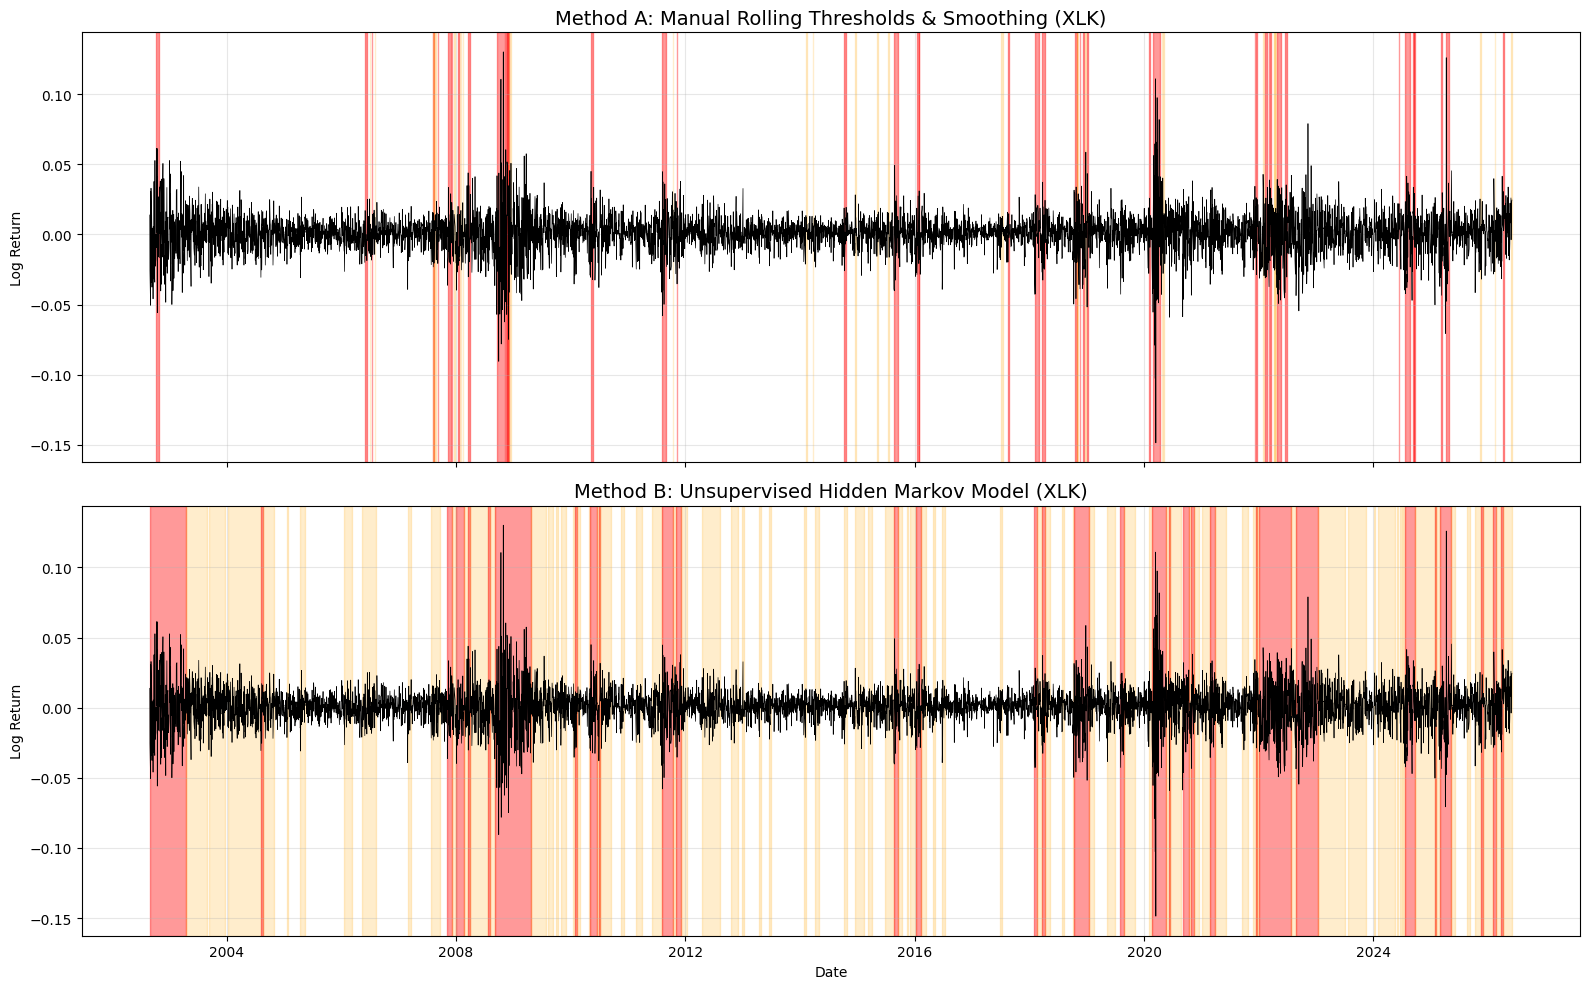

In [4]:
def plot_regime_comparison(df, title_suffix="XLK"):
    """
    Generates a stacked comparison chart of heuristic vs. statistical regimes.
    """
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    # Define colors for regimes (1 = Elevated (Orange), 2 = Shock (Red))
    color_map = {1: ('orange', 0.2), 2: ('red', 0.4)}
    
    # ---------------------------------------------------------
    # TOP PLOT: Smoothed Targets
    # ---------------------------------------------------------
    axes[0].plot(df.index, df['Log_Return'], color='black', linewidth=0.5)
    
    diff_smooth = df['Target_Smooth_10d'].diff().fillna(0)
    changes_smooth = df[diff_smooth != 0].index.tolist()
    changes_smooth.insert(0, df.index[0])
    changes_smooth.append(df.index[-1])
    
    for i in range(len(changes_smooth)-1):
        start, end = changes_smooth[i], changes_smooth[i+1]
        regime = df.loc[start, 'Target_Smooth_10d']
        if regime in color_map:
            color, alpha = color_map[regime]
            axes[0].axvspan(start, end, color=color, alpha=alpha)
            
    axes[0].set_title(f"Method A: Manual Rolling Thresholds & Smoothing ({title_suffix})", fontsize=14)
    axes[0].set_ylabel("Log Return")
    axes[0].grid(alpha=0.3)
    
    # ---------------------------------------------------------
    # BOTTOM PLOT: HMM Targets
    # ---------------------------------------------------------
    axes[1].plot(df.index, df['Log_Return'], color='black', linewidth=0.5)
    
    diff_hmm = df['Target_HMM'].diff().fillna(0)
    changes_hmm = df[diff_hmm != 0].index.tolist()
    changes_hmm.insert(0, df.index[0])
    changes_hmm.append(df.index[-1])
    
    for i in range(len(changes_hmm)-1):
        start, end = changes_hmm[i], changes_hmm[i+1]
        regime = df.loc[start, 'Target_HMM']
        if regime in color_map:
            color, alpha = color_map[regime]
            axes[1].axvspan(start, end, color=color, alpha=alpha)
            
    axes[1].set_title(f"Method B: Unsupervised Hidden Markov Model ({title_suffix})", fontsize=14)
    axes[1].set_ylabel("Log Return")
    axes[1].set_xlabel("Date")
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Execute the plotting function
plot_regime_comparison(comparison_df)

In [6]:
# 1. Generate the 4-State HMM
# We change n_components to 4
hmm_4_df = regimes.generate_hmm_targets(garch_df, feature_cols=['Log_Return', 'Vol_EGARCH'], n_components=4)

# 2. Add it to our master comparison dataframe
comparison_df = pd.concat([garch_df['Log_Return'], smooth_df, hmm_4_df], axis=1, join='inner')
comparison_df['Target_Smooth_10d'] = comparison_df['Target_Smooth_10d'].astype(int)
comparison_df['Target_HMM'] = comparison_df['Target_HMM'].astype(int)

# 3. Print the new distributions
print("\n" + "="*50)
print("Testing 4-State HMM Distribution")
print("="*50)
print(comparison_df['Target_HMM'].value_counts().sort_index())


--- HMM Generation Process ---
HMM State 0 Average Volatility: 0.8263
HMM State 1 Average Volatility: 1.7679
HMM State 2 Average Volatility: 2.7639
HMM State 3 Average Volatility: 1.2253
Mapping Order (Lowest Vol to Highest Vol): [0, 3, 1, 2]
HMM Target generation complete. Shape: (6227, 1)


Testing 4-State HMM Distribution
Target_HMM
0    2322
1    2045
2    1194
3     415
Name: count, dtype: int64


In [8]:
# Map the 4-state HMM down to 3 classes for Machine Learning
mapping_dict = {
    0: 0,  # Calm (Lowest vol: 0.82) -> Becomes Class 0
    1: 0,  # Calm (Normal vol: 1.22) -> Becomes Class 0
    2: 1,  # Elevated (High vol: 1.76) -> Becomes Class 1
    3: 2   # Shock (Crash vol: 2.76) -> Becomes Class 2
}

# Apply the mapping
comparison_df['Target_HMM'] = comparison_df['Target_HMM'].map(mapping_dict)

print("="*50)
print("FINAL MACHINE LEARNING TARGET DISTRIBUTION (HMM)")
print("="*50)
print(comparison_df['Target_HMM'].value_counts().sort_index())

FINAL MACHINE LEARNING TARGET DISTRIBUTION (HMM)
Target_HMM
0    4367
1    1194
2     415
Name: count, dtype: int64


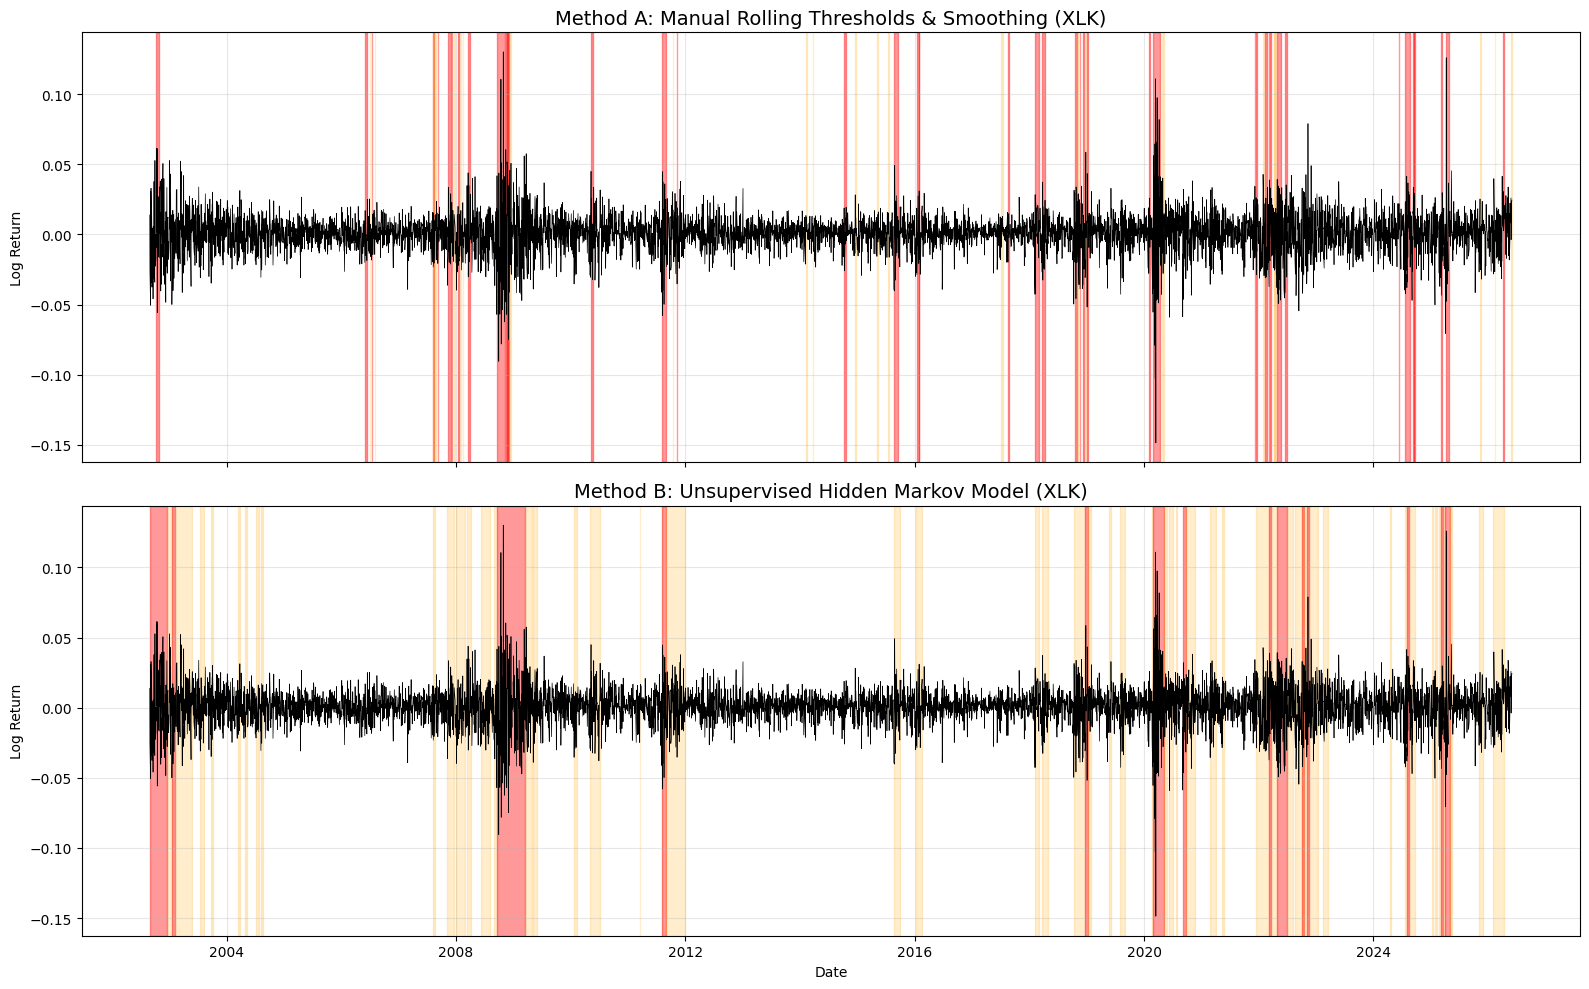

In [9]:
plot_regime_comparison(comparison_df)

In [1]:
# 1. Imports
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, volatility, regimes, config

# 2. Standard Ingest and ML-Safe Features
raw_df = data_loader.fetch_raw_data()
stat_df = features.engineer_stationary_features(raw_df)

# Note: Dynamic Winsorization natively handles Black Swans now
garch_df = volatility.generate_expanding_garch(stat_df, window_size=252, refit_freq=21)

# 3. Generate Targets
smooth_df = regimes.generate_smoothed_targets(
    garch_df, lower_quant=0.85, upper_quant=0.95, window=252
)

# New: Industry-Standard Expanding HMM
# Using a 504-day (2 year) initial window to give the HMM plenty of history 
# before it starts making out-of-sample predictions.
hmm_df = regimes.generate_expanding_hmm_targets(
    garch_df, 
    feature_cols=['Log_Return', 'Vol_EGARCH'], 
    vol_col='Vol_EGARCH',
    n_components=3,
    min_window=504,
    refit_freq=21
)

# 4. Robust Concatenation via Inner Join
comparison_df = pd.concat([garch_df['Log_Return'], smooth_df, hmm_df], axis=1, join='inner')

# Print Final Distributions
print("="*50)
print("Target Class Distributions (Strictly Out-of-Sample)")
print("="*50)
print("\nMethod A: 10-day Smoothed Targets:")
print(comparison_df['Target_Smooth_10d'].value_counts().sort_index())

print("\nMethod B: Expanding 3-State HMM Targets:")
print(comparison_df['Target_HMM'].value_counts().sort_index())


2026-06-04 10:57:18 - src.data_loader - INFO - Loading cached master raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...
2026-06-04 10:57:18 - src.features - INFO - Engineering stationary features and applying macro lags...
2026-06-04 10:57:18 - src.features - INFO - Stationary transformation complete. Final shape: (6469, 8)
2026-06-04 10:57:18 - src.volatility - INFO - Generating Expanding GARCH & EGARCH (Window: 252, Refit: 21 days)...
2026-06-04 10:57:31 - src.volatility - INFO - Out-of-sample generation complete. Shape: (6217, 10)
2026-06-04 10:57:31 - src.regimes - INFO - Generating rolling heuristic regimes and smoothed targets...
2026-06-04 10:57:31 - src.regimes - INFO - Smoothed heuristic targets generated. Shape: (5965, 1)
2026-06-04 10:57:31 - src.regimes - INFO - Starting Expanding HMM (Min Window: 504, Refit: 21 days)...
2026-06-04 10:59:47 - src.regimes - INFO - Expanding HMM Target generation complete. Shape: (5713, 1)


Target Class Distributions (Strictly Out-of-Sample)

Method A: 10-day Smoothed Targets:
Target_Smooth_10d
0    5245
1     106
2     362
Name: count, dtype: int64

Method B: Expanding 3-State HMM Targets:
Target_HMM
0    3103
1    1724
2     886
Name: count, dtype: int64


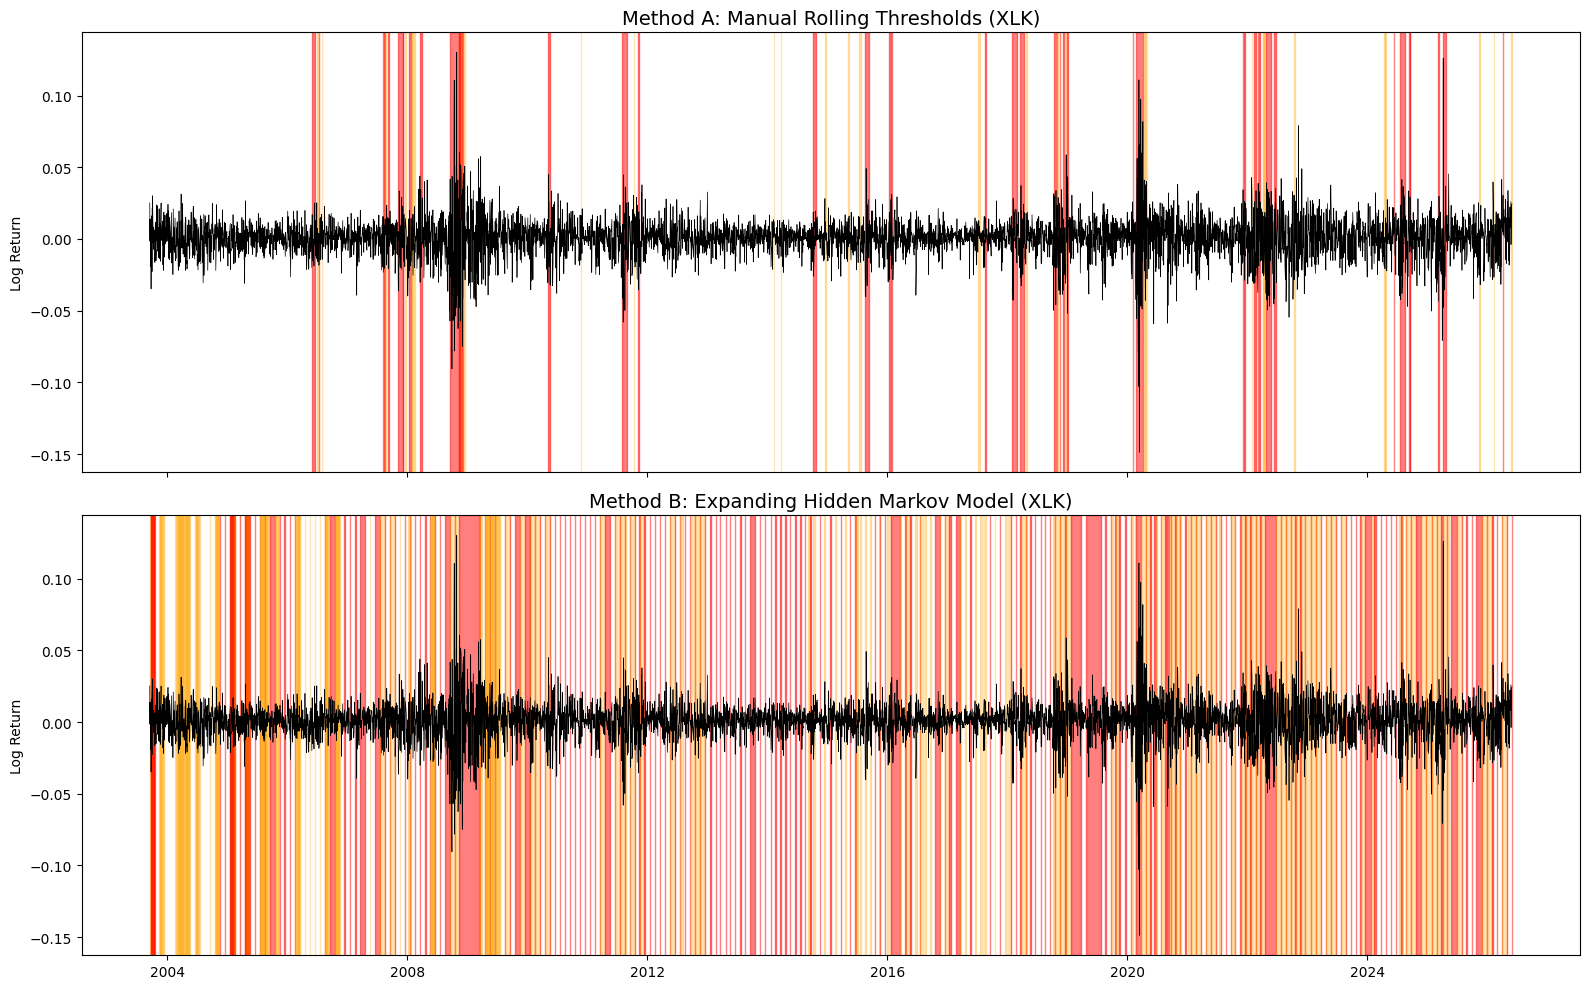

In [2]:
# ---------------------------------------------------------
# Plotting Function
# ---------------------------------------------------------
def plot_regime_comparison(df, title_suffix="XLK"):
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    color_map = {1: ('orange', 0.3), 2: ('red', 0.5)}
    
    # TOP: Smoothed
    axes[0].plot(df.index, df['Log_Return'], color='black', linewidth=0.5)
    diff_smooth = df['Target_Smooth_10d'].diff().fillna(0)
    changes_smooth = df[diff_smooth != 0].index.tolist()
    changes_smooth.insert(0, df.index[0])
    changes_smooth.append(df.index[-1])
    
    for i in range(len(changes_smooth)-1):
        start, end = changes_smooth[i], changes_smooth[i+1]
        regime = df.loc[start, 'Target_Smooth_10d']
        if regime in color_map:
            color, alpha = color_map[regime]
            axes[0].axvspan(start, end, color=color, alpha=alpha)
            
    axes[0].set_title(f"Method A: Manual Rolling Thresholds ({title_suffix})", fontsize=14)
    axes[0].set_ylabel("Log Return")
    
    # BOTTOM: HMM
    axes[1].plot(df.index, df['Log_Return'], color='black', linewidth=0.5)
    diff_hmm = df['Target_HMM'].diff().fillna(0)
    changes_hmm = df[diff_hmm != 0].index.tolist()
    changes_hmm.insert(0, df.index[0])
    changes_hmm.append(df.index[-1])
    
    for i in range(len(changes_hmm)-1):
        start, end = changes_hmm[i], changes_hmm[i+1]
        regime = df.loc[start, 'Target_HMM']
        if regime in color_map:
            color, alpha = color_map[regime]
            axes[1].axvspan(start, end, color=color, alpha=alpha)
            
    axes[1].set_title(f"Method B: Expanding Hidden Markov Model ({title_suffix})", fontsize=14)
    axes[1].set_ylabel("Log Return")
    
    plt.tight_layout()
    plt.show()

plot_regime_comparison(comparison_df)


2026-06-04 10:59:49 - src.regimes - INFO - Starting Expanding HMM (Min Window: 504, Refit: 21 days)...



--- Generating 4-State HMM ---


2026-06-04 10:59:56 - hmmlearn.base - WARNING - Model is not converging.  Current: -501.1340436937427 is not greater than -501.1305586389185. Delta is -0.0034850548241820434
2026-06-04 10:59:59 - hmmlearn.base - WARNING - Model is not converging.  Current: -275.6650844259672 is not greater than -275.6628006902274. Delta is -0.0022837357398088898
2026-06-04 11:00:00 - hmmlearn.base - WARNING - Model is not converging.  Current: -199.42726472275257 is not greater than -199.30528253835325. Delta is -0.12198218439931452
2026-06-04 11:00:01 - hmmlearn.base - WARNING - Model is not converging.  Current: -211.4062712178146 is not greater than -211.3512045668926. Delta is -0.055066650922015015
2026-06-04 11:00:03 - hmmlearn.base - WARNING - Model is not converging.  Current: -229.96284013582402 is not greater than -229.9583398652935. Delta is -0.004500270530513717
2026-06-04 11:00:09 - hmmlearn.base - WARNING - Model is not converging.  Current: -474.61540772995824 is not greater than -474.614


FINAL MACHINE LEARNING TARGET DISTRIBUTION (4-State mapped to 3)
Target_HMM
0    4079
1    1226
2     408
Name: count, dtype: int64


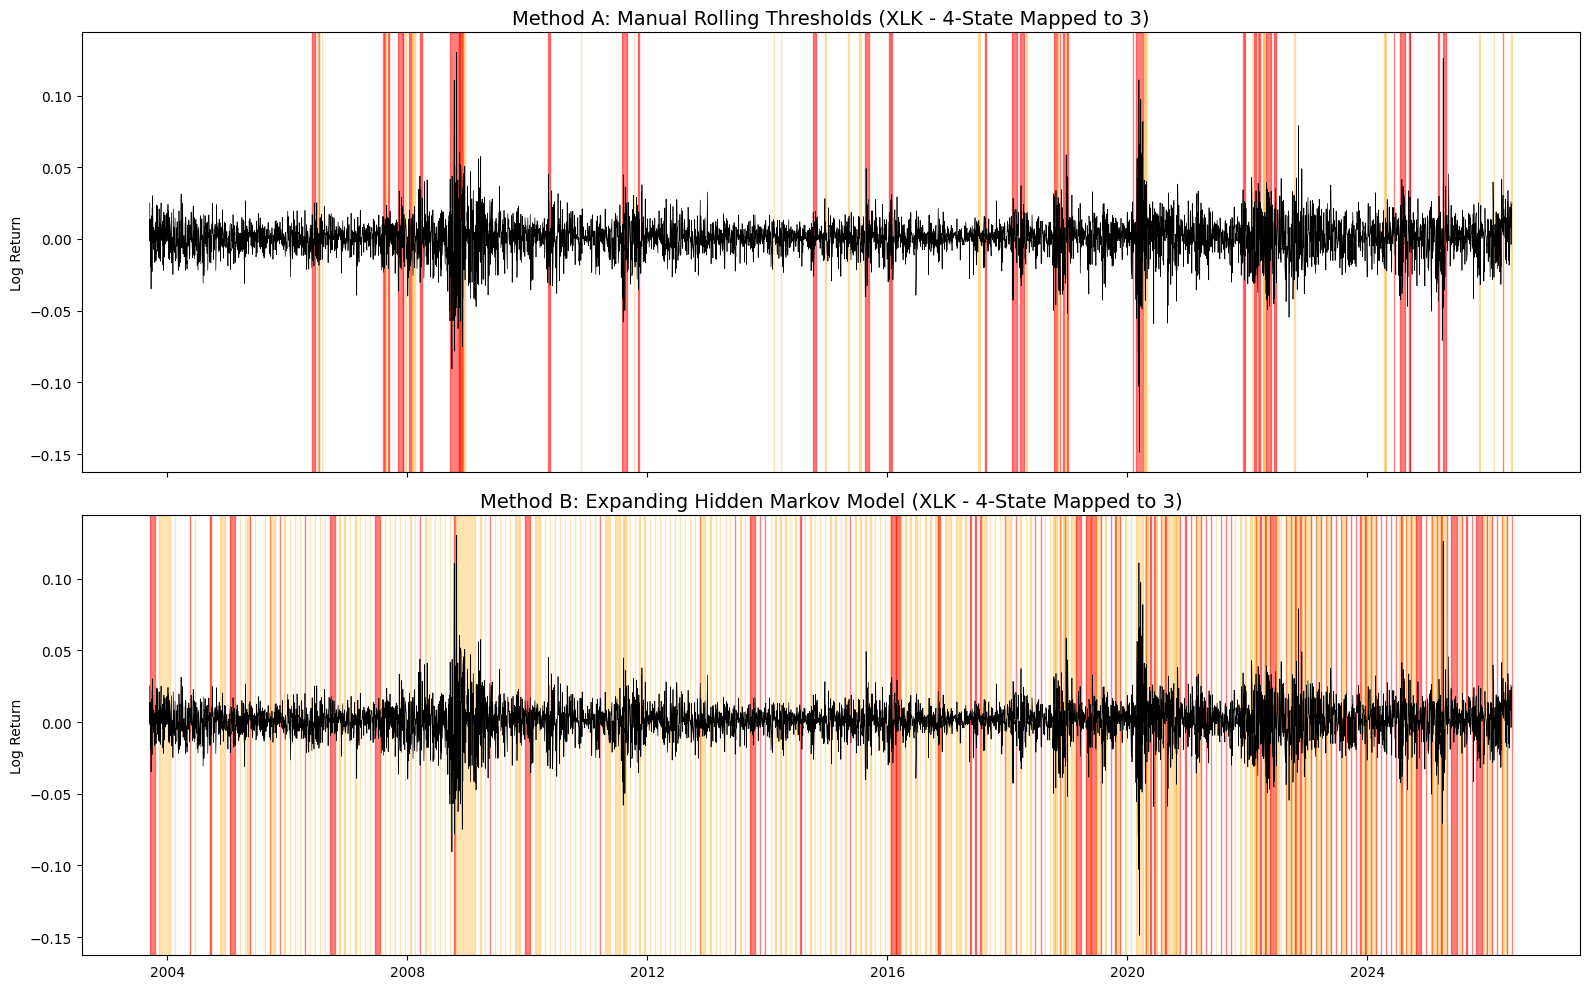

In [3]:
# ---------------------------------------------------------
# Testing the 4-State HMM Mapped to 3 Classes
# ---------------------------------------------------------
print("\n--- Generating 4-State HMM ---")
hmm_4_df = regimes.generate_expanding_hmm_targets(
    garch_df, 
    feature_cols=['Log_Return', 'Vol_EGARCH'], 
    vol_col='Vol_EGARCH',
    n_components=4,
    min_window=504,
    refit_freq=21
)

# Merge
comparison_4_df = pd.concat([garch_df['Log_Return'], smooth_df, hmm_4_df], axis=1, join='inner')

# Map the 4-state HMM down to 3 classes
# Because the src code guarantees State 0 is always lowest vol and State 3 is highest,
# this mapping is completely safe and won't be scrambled by label switching.
mapping_dict = {
    0: 0,  # Dead Calm -> Calm
    1: 0,  # Normal -> Calm
    2: 1,  # Elevated
    3: 2   # Shock
}

comparison_4_df['Target_HMM'] = comparison_4_df['Target_HMM'].map(mapping_dict)

print("\n" + "="*50)
print("FINAL MACHINE LEARNING TARGET DISTRIBUTION (4-State mapped to 3)")
print("="*50)
print(comparison_4_df['Target_HMM'].value_counts().sort_index())

plot_regime_comparison(comparison_4_df, title_suffix="XLK - 4-State Mapped to 3")
